In [54]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [58]:
!pip install -q timm


In [59]:
import os
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

import timm
from torchvision import transforms


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


In [61]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("TIMM version loaded")


Torch version: 2.9.0+cu126
CUDA available: True
TIMM version loaded


In [62]:
DATASET_ROOT = "/content/drive/MyDrive/morph_project/extracted_datasets/CASIA2"

AU_DIR = os.path.join(DATASET_ROOT, "Au")
TP_DIR = os.path.join(DATASET_ROOT, "Tp")

print("Authentic dir exists:", os.path.exists(AU_DIR))
print("Tampered dir exists :", os.path.exists(TP_DIR))


Authentic dir exists: True
Tampered dir exists : True


In [63]:
def get_image_paths(folder):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(exts)
    ]

au_images = get_image_paths(AU_DIR)
tp_images = get_image_paths(TP_DIR)

print(f"Total Authentic images: {len(au_images)}")
print(f"Total Tampered images : {len(tp_images)}")


Total Authentic images: 7491
Total Tampered images : 1553


In [64]:
from sklearn.model_selection import train_test_split

# Labels
au_labels = [0] * len(au_images)
tp_labels = [1] * len(tp_images)

# Combine
all_images = au_images + tp_images
all_labels = au_labels + tp_labels

# Train / Test split
_, test_images, _, test_labels = train_test_split(
    all_images,
    all_labels,
    test_size=0.20,
    stratify=all_labels,
    random_state=SEED
)


In [65]:
import numpy as np

test_labels = np.array(test_labels)

print("Test set size:", len(test_images))
print("Authentic (0):", np.sum(test_labels == 0))
print("Tampered  (1):", np.sum(test_labels == 1))


Test set size: 1809
Authentic (0): 1498
Tampered  (1): 311


In [66]:
test_au = [img for img, lbl in zip(test_images, test_labels) if lbl == 0]
test_tp = [img for img, lbl in zip(test_images, test_labels) if lbl == 1]

print("Test Authentic:", len(test_au))
print("Test Tampered :", len(test_tp))


Test Authentic: 1498
Test Tampered : 311


In [67]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [68]:
def preprocess_image(image_path, device):
    image = Image.open(image_path).convert("RGB")
    image = inference_transform(image)
    image = image.unsqueeze(0)  # shape: [1, 3, 224, 224]
    return image.to(device)


In [69]:
sample_img = test_images[0]
x = preprocess_image(sample_img, device)

print("Input shape:", x.shape)
print("Input device:", x.device)
print("Min / Max:", x.min().item(), x.max().item())


Input shape: torch.Size([1, 3, 224, 224])
Input device: cuda:0
Min / Max: -2.1179039478302 1.9383753538131714


In [70]:
VIT_PATH  = "/content/drive/MyDrive/morph_project/models/vit_advanced.pth"
EFF_PATH  = "/content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth"
CONV_PATH = "/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth"
SWIN_PATH = "/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth"


In [71]:
for p in [VIT_PATH, EFF_PATH, CONV_PATH, SWIN_PATH]:
    print(p, "->", os.path.exists(p))


/content/drive/MyDrive/morph_project/models/vit_advanced.pth -> True
/content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth -> True
/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth -> True
/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth -> True


In [72]:
def load_state_dict_safely(model, checkpoint_path):
    state = torch.load(checkpoint_path, map_location="cpu")

    # Some checkpoints are saved as {"state_dict": ...}
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]

    new_state = {}
    for k, v in state.items():
        if k.startswith("backbone."):
            new_state[k.replace("backbone.", "")] = v
        else:
            new_state[k] = v

    missing, unexpected = model.load_state_dict(new_state, strict=False)

    print(f"\nLoaded: {os.path.basename(checkpoint_path)}")
    print("Missing keys   :", len(missing))
    print("Unexpected keys:", len(unexpected))


In [73]:
vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=2
)

load_state_dict_safely(vit_model, VIT_PATH)

vit_model = vit_model.to(device)
vit_model.eval()



Loaded: vit_advanced.pth
Missing keys   : 0
Unexpected keys: 0


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [74]:
eff_model = timm.create_model(
    "efficientnet_b3",
    pretrained=False,
    num_classes=2
)

load_state_dict_safely(eff_model, EFF_PATH)

eff_model = eff_model.to(device)
eff_model.eval()



Loaded: efficientnet_b3_tuned_baseline.pth
Missing keys   : 0
Unexpected keys: 0


EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [75]:
conv_model = timm.create_model(
    "convnextv2_tiny",
    pretrained=False,
    num_classes=2
)

load_state_dict_safely(conv_model, CONV_PATH)

conv_model = conv_model.to(device)
conv_model.eval()



Loaded: convnextv2_best_224_finetuned.pth
Missing keys   : 2
Unexpected keys: 4


ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), 

In [76]:
swin_model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=2
)

load_state_dict_safely(swin_model, SWIN_PATH)

swin_model = swin_model.to(device)
swin_model.eval()



Loaded: swin224_recall_tuned.pth
Missing keys   : 2
Unexpected keys: 4


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [77]:
x = preprocess_image(test_images[0], device)

with torch.no_grad():
    out_vit  = vit_model(x)
    out_eff  = eff_model(x)
    out_conv = conv_model(x)
    out_swin = swin_model(x)

print("ViT output shape :", out_vit.shape)
print("EffNet output   :", out_eff.shape)
print("ConvNeXt output :", out_conv.shape)
print("Swin output     :", out_swin.shape)


ViT output shape : torch.Size([1, 2])
EffNet output   : torch.Size([1, 2])
ConvNeXt output : torch.Size([1, 2])
Swin output     : torch.Size([1, 2])


In [78]:
def evaluate_model(model, model_name):
    y_true = []
    y_pred = []
    y_scores = []

    for img_path, label in tqdm(
        zip(test_images, test_labels),
        total=len(test_images),
        desc=f"Evaluating {model_name}"
    ):
        x = preprocess_image(img_path, device)

        with torch.no_grad():
            logits = model(x)
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]

        y_true.append(label)
        y_pred.append(probs.argmax())
        y_scores.append(probs[1])  # Illicit probability

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_scores),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

    return metrics


In [79]:
vit_metrics = evaluate_model(vit_model, "ViT")
eff_metrics = evaluate_model(eff_model, "EfficientNet-B3")
conv_metrics = evaluate_model(conv_model, "ConvNeXtV2-Tiny")
swin_metrics = evaluate_model(swin_model, "Swin-Tiny")


Evaluating Swin-Tiny: 100%|██████████| 1809/1809 [00:33<00:00, 54.02it/s]


In [80]:
def print_metrics(name, m):
    print(f"\n📊 {name} Results")
    print(f"Accuracy  : {m['accuracy']:.4f}")
    print(f"Precision : {m['precision']:.4f}")
    print(f"Recall    : {m['recall']:.4f}")
    print(f"F1-score  : {m['f1']:.4f}")
    print(f"ROC-AUC   : {m['roc_auc']:.4f}")
    print("Confusion Matrix:\n", m["confusion_matrix"])


In [81]:
print_metrics("ViT", vit_metrics)
print_metrics("EfficientNet-B3", eff_metrics)
print_metrics("ConvNeXtV2-Tiny", conv_metrics)
print_metrics("Swin-Tiny", swin_metrics)



📊 ViT Results
Accuracy  : 0.9132
Precision : 0.7104
Recall    : 0.8360
F1-score  : 0.7681
ROC-AUC   : 0.9474
Confusion Matrix:
 [[1392  106]
 [  51  260]]

📊 EfficientNet-B3 Results
Accuracy  : 0.4378
Precision : 0.1914
Recall    : 0.7042
F1-score  : 0.3010
ROC-AUC   : 0.5511
Confusion Matrix:
 [[573 925]
 [ 92 219]]

📊 ConvNeXtV2-Tiny Results
Accuracy  : 0.5981
Precision : 0.1579
Recall    : 0.3087
F1-score  : 0.2089
ROC-AUC   : 0.4575
Confusion Matrix:
 [[986 512]
 [215  96]]

📊 Swin-Tiny Results
Accuracy  : 0.4815
Precision : 0.1830
Recall    : 0.5820
F1-score  : 0.2785
ROC-AUC   : 0.5353
Confusion Matrix:
 [[690 808]
 [130 181]]


In [82]:
model_metrics = {
    "ViT": vit_metrics,
    "EfficientNet-B3": eff_metrics,
    "ConvNeXtV2-Tiny": conv_metrics,
    "Swin-Tiny": swin_metrics
}


In [83]:
raw_scores = {}

for name, m in model_metrics.items():
    score = (
        0.5 * m["recall"] +
        0.3 * m["roc_auc"] +
        0.2 * m["precision"]
    )
    raw_scores[name] = score

raw_scores


{'ViT': np.float64(0.8443165741672513),
 'EfficientNet-B3': np.float64(0.5556949188684321),
 'ConvNeXtV2-Tiny': np.float64(0.32317030819679243),
 'Swin-Tiny': np.float64(0.48819746705168765)}

In [84]:
total_score = sum(raw_scores.values())

weights = {
    name: score / total_score
    for name, score in raw_scores.items()
}

weights


{'ViT': np.float64(0.3818054127017148),
 'EfficientNet-B3': np.float64(0.2512888344565167),
 'ConvNeXtV2-Tiny': np.float64(0.14613970241637664),
 'Swin-Tiny': np.float64(0.22076605042539177)}

In [85]:
print("\n🔒 Final Ensemble Weights (Locked)")
for k, v in weights.items():
    print(f"{k:<22}: {v:.4f}")



🔒 Final Ensemble Weights (Locked)
ViT                   : 0.3818
EfficientNet-B3       : 0.2513
ConvNeXtV2-Tiny       : 0.1461
Swin-Tiny             : 0.2208


In [86]:
class WeightedSoftVotingEnsemble(nn.Module):
    def __init__(self, models, weights):
        """
        models  : dict of {name: nn.Module}
        weights : dict of {name: float}
        """
        super().__init__()
        self.models = nn.ModuleDict(models)
        self.weights = weights

    def forward(self, x):
        fused_probs = None

        for name, model in self.models.items():
            logits = model(x)
            probs = F.softmax(logits, dim=1)

            weight = self.weights[name]
            weighted_probs = weight * probs

            if fused_probs is None:
                fused_probs = weighted_probs
            else:
                fused_probs += weighted_probs

        return fused_probs  # shape: [B, 2]


In [87]:
ensemble_model = WeightedSoftVotingEnsemble(
    models={
        "ViT": vit_model,
        "EfficientNet-B3": eff_model,
        "ConvNeXtV2-Tiny": conv_model,
        "Swin-Tiny": swin_model
    },
    weights=weights
)

ensemble_model = ensemble_model.to(device)
ensemble_model.eval()


WeightedSoftVotingEnsemble(
  (models): ModuleDict(
    (ViT): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(

In [88]:
x = preprocess_image(test_images[0], device)

with torch.no_grad():
    fused_probs = ensemble_model(x)

print("Fused output shape:", fused_probs.shape)
print("Fused probabilities:", fused_probs.cpu().numpy())
print("Predicted class:", fused_probs.argmax(dim=1).item())


Fused output shape: torch.Size([1, 2])
Fused probabilities: [[0.5725601  0.42743993]]
Predicted class: 0


In [89]:
def predict_image(image_path):
    x = preprocess_image(image_path, device)
    with torch.no_grad():
        probs = ensemble_model(x)[0].cpu().numpy()

    label = probs.argmax()
    confidence = probs[label]

    return {
        "prediction": "Tampered (Illicit)" if label == 1 else "Authentic (Licit)",
        "confidence": float(confidence),
        "probs": probs
    }


In [90]:
ENSEMBLE_SAVE_PATH = "/content/drive/MyDrive/morph_project/fusion/final_weighted_soft_voting_ensemble.pth"
os.makedirs(os.path.dirname(ENSEMBLE_SAVE_PATH), exist_ok=True)


In [91]:
torch.save({
    "ensemble_state_dict": ensemble_model.state_dict(),
    "weights": weights,
    "model_names": list(weights.keys()),
    "class_mapping": {
        0: "Authentic (Licit)",
        1: "Tampered (Illicit)"
    }
}, ENSEMBLE_SAVE_PATH)

print("✅ Final ensemble saved to:", ENSEMBLE_SAVE_PATH)


✅ Final ensemble saved to: /content/drive/MyDrive/morph_project/fusion/final_weighted_soft_voting_ensemble.pth


In [ ]:
checkpoint = torch.load(ENSEMBLE_SAVE_PATH, map_location=device)
ensemble_model.load_state_dict(checkpoint["ensemble_state_dict"])


In [92]:
def evaluate_classifier(model, name):
    y_true, y_pred, y_scores = [], [], []

    for img_path, label in tqdm(
        zip(test_images, test_labels),
        total=len(test_images),
        desc=f"Evaluating {name}"
    ):
        x = preprocess_image(img_path, device)

        with torch.no_grad():
            probs = model(x)[0].cpu().numpy()

        y_true.append(label)
        y_pred.append(probs.argmax())
        y_scores.append(probs[1])

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_scores),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }

    return metrics


In [93]:
class SoftmaxWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return F.softmax(self.model(x), dim=1)


In [94]:
vit_eval  = evaluate_classifier(SoftmaxWrapper(vit_model), "ViT")
eff_eval  = evaluate_classifier(SoftmaxWrapper(eff_model), "EfficientNet-B3")
conv_eval = evaluate_classifier(SoftmaxWrapper(conv_model), "ConvNeXtV2-Tiny")
swin_eval = evaluate_classifier(SoftmaxWrapper(swin_model), "Swin-Tiny")


Evaluating Swin-Tiny: 100%|██████████| 1809/1809 [00:34<00:00, 52.41it/s]


In [95]:
ensemble_eval = evaluate_classifier(ensemble_model, "Final Weighted Ensemble")


Evaluating Final Weighted Ensemble: 100%|██████████| 1809/1809 [01:35<00:00, 18.95it/s]


In [96]:
def print_eval(name, m):
    print(f"\n📊 {name}")
    print(f"Accuracy  : {m['Accuracy']:.4f}")
    print(f"Precision : {m['Precision']:.4f}")
    print(f"Recall    : {m['Recall']:.4f}")
    print(f"F1-score  : {m['F1']:.4f}")
    print(f"ROC-AUC   : {m['ROC-AUC']:.4f}")
    print("Confusion Matrix:\n", m["Confusion Matrix"])


In [97]:
print_eval("ViT", vit_eval)
print_eval("EfficientNet-B3", eff_eval)
print_eval("ConvNeXtV2-Tiny", conv_eval)
print_eval("Swin-Tiny", swin_eval)
print_eval("Final Weighted Ensemble", ensemble_eval)



📊 ViT
Accuracy  : 0.9132
Precision : 0.7104
Recall    : 0.8360
F1-score  : 0.7681
ROC-AUC   : 0.9474
Confusion Matrix:
 [[1392  106]
 [  51  260]]

📊 EfficientNet-B3
Accuracy  : 0.4378
Precision : 0.1914
Recall    : 0.7042
F1-score  : 0.3010
ROC-AUC   : 0.5511
Confusion Matrix:
 [[573 925]
 [ 92 219]]

📊 ConvNeXtV2-Tiny
Accuracy  : 0.5981
Precision : 0.1579
Recall    : 0.3087
F1-score  : 0.2089
ROC-AUC   : 0.4575
Confusion Matrix:
 [[986 512]
 [215  96]]

📊 Swin-Tiny
Accuracy  : 0.4815
Precision : 0.1830
Recall    : 0.5820
F1-score  : 0.2785
ROC-AUC   : 0.5353
Confusion Matrix:
 [[690 808]
 [130 181]]

📊 Final Weighted Ensemble
Accuracy  : 0.8447
Precision : 0.5298
Recall    : 0.8585
F1-score  : 0.6552
ROC-AUC   : 0.9089
Confusion Matrix:
 [[1261  237]
 [  44  267]]


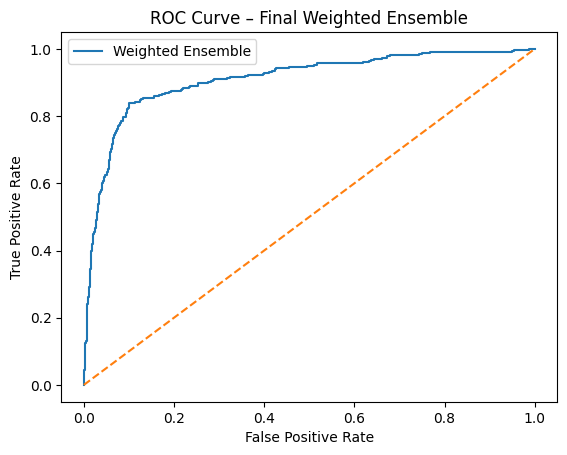

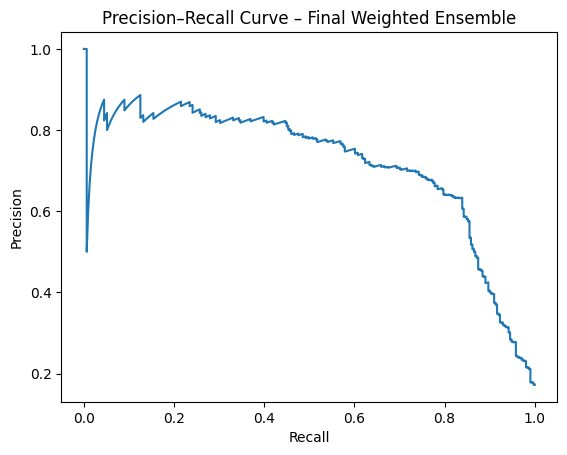

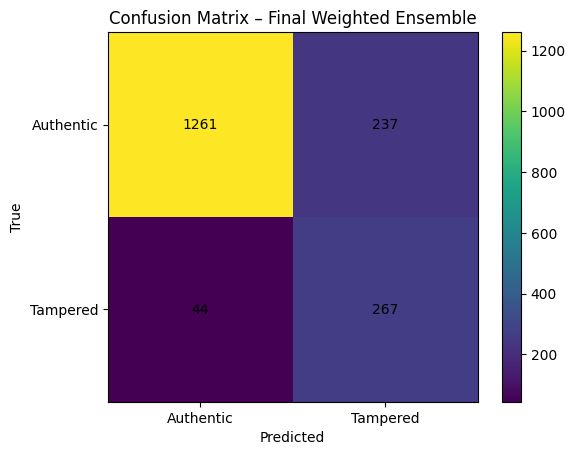

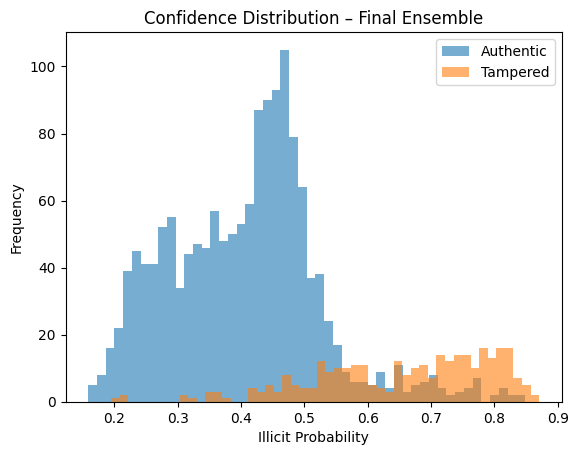

In [98]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

# --- Recompute predictions for plotting ---
y_true, y_pred, y_scores = [], [], []

for img_path, label in zip(test_images, test_labels):
    x = preprocess_image(img_path, device)
    with torch.no_grad():
        probs = ensemble_model(x)[0].cpu().numpy()

    y_true.append(label)
    y_pred.append(probs.argmax())
    y_scores.append(probs[1])  # illicit probability

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# --- 1. ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.figure()
plt.plot(fpr, tpr, label="Weighted Ensemble")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Final Weighted Ensemble")
plt.legend()
plt.show()

# --- 2. Precision–Recall Curve ---
precision, recall, _ = precision_recall_curve(y_true, y_scores)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Final Weighted Ensemble")
plt.show()

# --- 3. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.xticks([0, 1], ["Authentic", "Tampered"])
plt.yticks([0, 1], ["Authentic", "Tampered"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Final Weighted Ensemble")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# --- 4. Confidence Distribution ---
plt.figure()
plt.hist(y_scores[y_true == 0], bins=50, alpha=0.6, label="Authentic")
plt.hist(y_scores[y_true == 1], bins=50, alpha=0.6, label="Tampered")
plt.xlabel("Illicit Probability")
plt.ylabel("Frequency")
plt.title("Confidence Distribution – Final Ensemble")
plt.legend()
plt.show()


In [102]:
# ================================
# FINAL WEIGHTED ENSEMBLE INFERENCE
# ================================

# ---- 1. Mount Drive (safe even if already mounted)
from google.colab import drive, files
drive.mount("/content/drive", force_remount=True)

# ---- 2. Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import cv2

# ---- 3. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- 4. Preprocessing (ImageNet-based, inference-safe)
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img.astype(np.float32) / 255.0   # already float32

    img = (img - MEAN) / (STD + 1e-7)

    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)
    img = img.float()                      # 🔥 FORCE float32
    return img.to(device)


# ---- 5. Load Base Models (exact architectures)
vit  = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
eff  = timm.create_model("efficientnet_b3", pretrained=False, num_classes=2)
conv = timm.create_model("convnextv2_tiny", pretrained=False, num_classes=2)
swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=2)

# ---- 6. Safe checkpoint loader
def load_ckpt(model, path):
    state = torch.load(path, map_location="cpu")
    new_state = {}
    for k, v in state.items():
        if k.startswith("backbone."):
            new_state[k.replace("backbone.", "")] = v
        else:
            new_state[k] = v
    model.load_state_dict(new_state, strict=False)

# ---- 7. Load trained weights from Drive
load_ckpt(vit,  "/content/drive/MyDrive/morph_project/models/vit_advanced.pth")
load_ckpt(eff,  "/content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth")
load_ckpt(conv, "/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth")
load_ckpt(swin, "/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth")

models = {
    "ViT": vit.to(device).eval(),
    "EfficientNet-B3": eff.to(device).eval(),
    "ConvNeXtV2-Tiny": conv.to(device).eval(),
    "Swin-Tiny": swin.to(device).eval()
}

# ---- 8. Final locked ensemble weights
weights = {
    "ViT": 0.3818,
    "EfficientNet-B3": 0.2513,
    "ConvNeXtV2-Tiny": 0.1461,
    "Swin-Tiny": 0.2208
}

# ---- 9. Weighted Soft Voting Ensemble
class WeightedSoftVotingEnsemble(nn.Module):
    def __init__(self, models, weights):
        super().__init__()
        self.models = nn.ModuleDict(models)
        self.weights = weights

    def forward(self, x):
        fused = None
        for name, model in self.models.items():
            probs = F.softmax(model(x), dim=1)
            w = self.weights[name]
            fused = probs * w if fused is None else fused + probs * w
        return fused

ensemble = WeightedSoftVotingEnsemble(models, weights).to(device).eval()

# ---- 10. Prediction function
def predict(path):
    img = preprocess(path)
    with torch.no_grad():
        probs = ensemble(img)[0].cpu().numpy()

    cls = np.argmax(probs)
    conf = probs[cls] * 100

    print("\n=======================")
    print("Image:", path)
    print("Prediction:", "Authentic (0)" if cls == 0 else "Tampered (1)")
    print(f"Confidence: {conf:.2f}%")
    print("Probabilities:", probs)
    print("=======================\n")

# ---- 11. Upload image(s) from PC or Drive
uploaded = files.upload()
for name in uploaded:
    predict(name)


Mounted at /content/drive
Using device: cuda


Saving casias1.png to casias1.png

Image: casias1.png
Prediction: Tampered (1)
Confidence: 71.65%
Probabilities: [0.2834805 0.7165195]

